## Data Set Prep

In [1]:
!pip install -q kaggle pillow

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"shayanrehman223","key":"39b38ad43e983b9e76e3dd5dd6e9c487"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d vishesh1412/celebrity-face-image-dataset
!unzip -q celebrity-face-image-dataset.zip -d celebrity_data

Dataset URL: https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset
License(s): CC0-1.0
 55% 29.0M/52.9M [00:00<00:00, 292MB/s]
100% 52.9M/52.9M [00:00<00:00, 276MB/s]


In [5]:
import os

base_dir = "celebrity_data/Celebrity Faces Dataset"

people = sorted([f for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))])

print("Number of people found:", len(people))
print(people[:50])  # first 50 names

Number of people found: 17
['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']


In [6]:
import os
import shutil
from sklearn.model_selection import train_test_split

# Choose the target person
target_person = "Scarlett Johansson"

source_dir = "celebrity_data/Celebrity Faces Dataset"
working_dir = "face_binary_dataset"

train_target_dir = os.path.join(working_dir, "train", "target")
train_not_dir    = os.path.join(working_dir, "train", "not_target")
val_target_dir   = os.path.join(working_dir, "val", "target")
val_not_dir      = os.path.join(working_dir, "val", "not_target")
test_target_dir  = os.path.join(working_dir, "test", "target")
test_not_dir     = os.path.join(working_dir, "test", "not_target")

for d in [train_target_dir, train_not_dir, val_target_dir, val_not_dir, test_target_dir, test_not_dir]:
    os.makedirs(d, exist_ok=True)

all_people = sorted(os.listdir(source_dir))

target_files = []
not_target_files = []

for person in all_people:
    person_dir = os.path.join(source_dir, person)

    files = [
        os.path.join(person_dir, f)
        for f in os.listdir(person_dir)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ]

    if person == target_person:
        target_files.extend(files)
    else:
        not_target_files.extend(files)

print("Target images:", len(target_files))
print("Not-target images:", len(not_target_files))

Target images: 200
Not-target images: 1600


In [7]:
import random

random.seed(42)

max_not_target = min(len(not_target_files), len(target_files) * 3)

not_target_files = random.sample(not_target_files, max_not_target)

print("Balanced target images:", len(target_files))
print("Balanced not-target images:", len(not_target_files))

Balanced target images: 200
Balanced not-target images: 600


In [8]:
def split_files(file_list, train_size=0.7, val_size=0.15, test_size=0.15):

    train_files, temp_files = train_test_split(
        file_list,
        test_size=(1-train_size),
        random_state=42
    )

    val_ratio = val_size / (val_size + test_size)

    val_files, test_files = train_test_split(
        temp_files,
        test_size=(1-val_ratio),
        random_state=42
    )

    return train_files, val_files, test_files


target_train, target_val, target_test = split_files(target_files)
not_train, not_val, not_test = split_files(not_target_files)

print("Target split:", len(target_train), len(target_val), len(target_test))
print("Not-target split:", len(not_train), len(not_val), len(not_test))

Target split: 139 30 31
Not-target split: 419 90 91


In [9]:
def copy_files(file_list, destination, prefix):

    for i, src in enumerate(file_list):

        ext = os.path.splitext(src)[1]

        dst = os.path.join(destination, f"{prefix}_{i}{ext}")

        shutil.copy(src, dst)


copy_files(target_train, train_target_dir, "target")
copy_files(target_val, val_target_dir, "target")
copy_files(target_test, test_target_dir, "target")

copy_files(not_train, train_not_dir, "not_target")
copy_files(not_val, val_not_dir, "not_target")
copy_files(not_test, test_not_dir, "not_target")

print("Dataset folders created.")

Dataset folders created.


In [10]:
from PIL import Image

def clean_folder(folder):

    removed = 0

    for fname in os.listdir(folder):

        path = os.path.join(folder, fname)

        try:
            with Image.open(path) as img:
                img.verify()

        except:
            os.remove(path)
            removed += 1

    return removed


all_folders = [
    train_target_dir,
    train_not_dir,
    val_target_dir,
    val_not_dir,
    test_target_dir,
    test_not_dir
]

for folder in all_folders:

    removed = clean_folder(folder)

    print(folder, "removed:", removed)

face_binary_dataset/train/target removed: 0
face_binary_dataset/train/not_target removed: 0
face_binary_dataset/val/target removed: 0
face_binary_dataset/val/not_target removed: 0
face_binary_dataset/test/target removed: 0
face_binary_dataset/test/not_target removed: 0


In [11]:
def count_images(folder):

    return len([
        f for f in os.listdir(folder)
        if f.lower().endswith((".jpg",".jpeg",".png"))
    ])


print("TRAIN target:", count_images(train_target_dir))
print("TRAIN not_target:", count_images(train_not_dir))

print("VAL target:", count_images(val_target_dir))
print("VAL not_target:", count_images(val_not_dir))

print("TEST target:", count_images(test_target_dir))
print("TEST not_target:", count_images(test_not_dir))

TRAIN target: 139
TRAIN not_target: 419
VAL target: 30
VAL not_target: 90
TEST target: 31
TEST not_target: 91


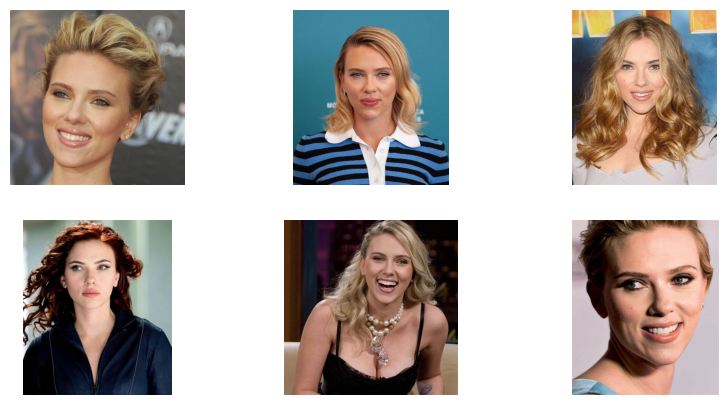

In [12]:
import matplotlib.pyplot as plt
from PIL import Image
import random

sample_folder = train_target_dir

sample_files = random.sample(os.listdir(sample_folder), 6)

plt.figure(figsize=(10,5))

for i,f in enumerate(sample_files):

    img = Image.open(os.path.join(sample_folder,f))

    plt.subplot(2,3,i+1)

    plt.imshow(img)

    plt.axis("off")

plt.show()

## Imports


In [13]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

## Device Setup

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## Data Preprocessing and Augmentation


In [15]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Loading the Dataset


In [16]:
train_dir = "face_binary_dataset/train"
val_dir   = "face_binary_dataset/val"
test_dir  = "face_binary_dataset/test"

train_data = datasets.ImageFolder(train_dir, transform=train_transforms)
val_data   = datasets.ImageFolder(val_dir, transform=test_transforms)
test_data  = datasets.ImageFolder(test_dir, transform=test_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

class_names = train_data.classes
print("Classes:", class_names)

Classes: ['not_target', 'target']


## Dataset Sizes


In [17]:
print("Training images:", len(train_data))
print("Validation images:", len(val_data))
print("Test images:", len(test_data))

Training images: 558
Validation images: 120
Test images: 122


## Sample Training Images

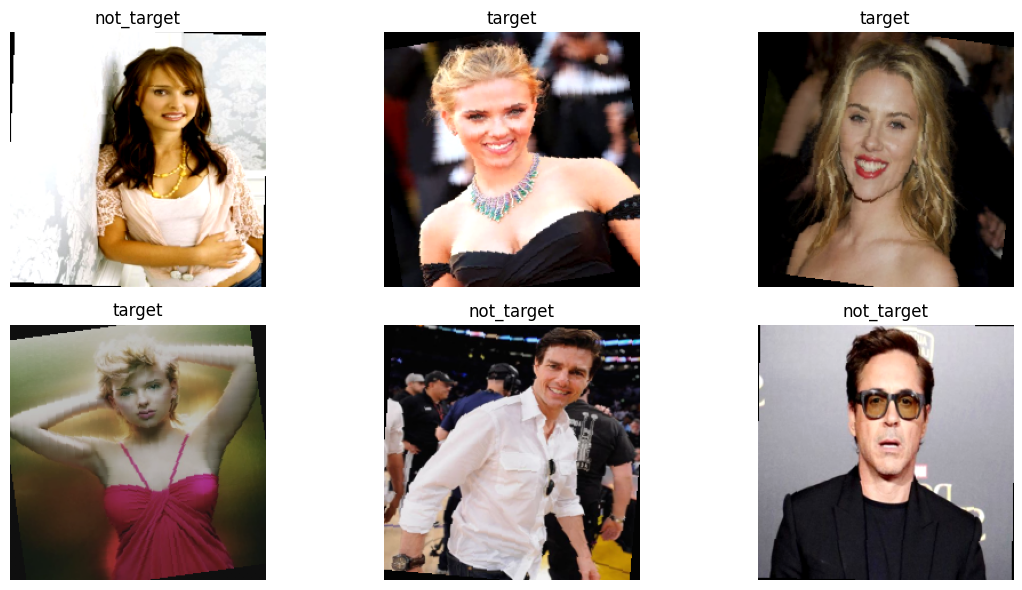

In [18]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## Transfer Learning Model

In [19]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 102MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## Loss Function and Optimizer


In [20]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

## Training the Model

In [21]:
epochs = 6

train_losses = []
val_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (preds == labels).sum().item()

    val_acc = correct / total
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Accuracy: {val_acc:.4f}")

Epoch 1/6 | Train Loss: 0.5333 | Val Accuracy: 0.7500
Epoch 2/6 | Train Loss: 0.4179 | Val Accuracy: 0.8083
Epoch 3/6 | Train Loss: 0.3894 | Val Accuracy: 0.8250
Epoch 4/6 | Train Loss: 0.3239 | Val Accuracy: 0.8583
Epoch 5/6 | Train Loss: 0.3220 | Val Accuracy: 0.8583
Epoch 6/6 | Train Loss: 0.3186 | Val Accuracy: 0.8667


## Training Loss


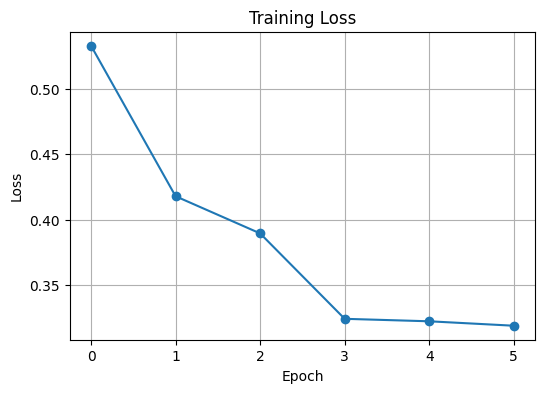

In [22]:
plt.figure(figsize=(6, 4))
plt.plot(train_losses, marker="o")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Validation Accuracy

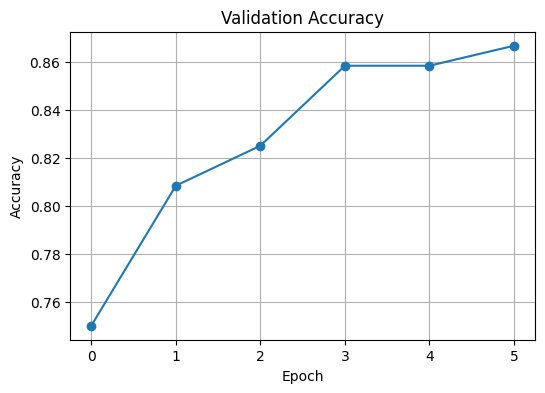

In [23]:
plt.figure(figsize=(6, 4))
plt.plot(val_accuracies, marker="o")
plt.title("Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Test Set Evaluation

In [24]:
model.eval()
correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = correct / total
print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8688524590163934


## Confusion Matrix

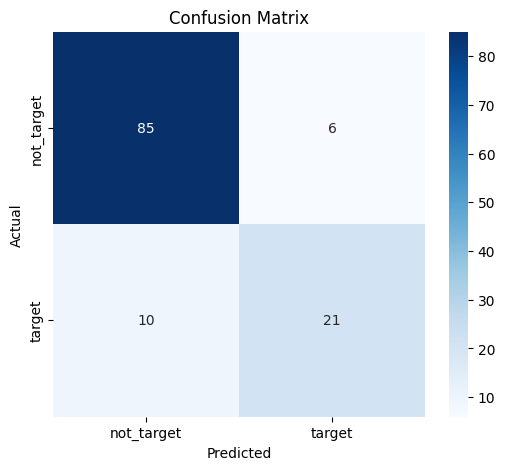

In [25]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Classification Report


In [26]:
print(classification_report(all_labels, all_preds, target_names=class_names))

              precision    recall  f1-score   support

  not_target       0.89      0.93      0.91        91
      target       0.78      0.68      0.72        31

    accuracy                           0.87       122
   macro avg       0.84      0.81      0.82       122
weighted avg       0.87      0.87      0.87       122



## Example Predictions


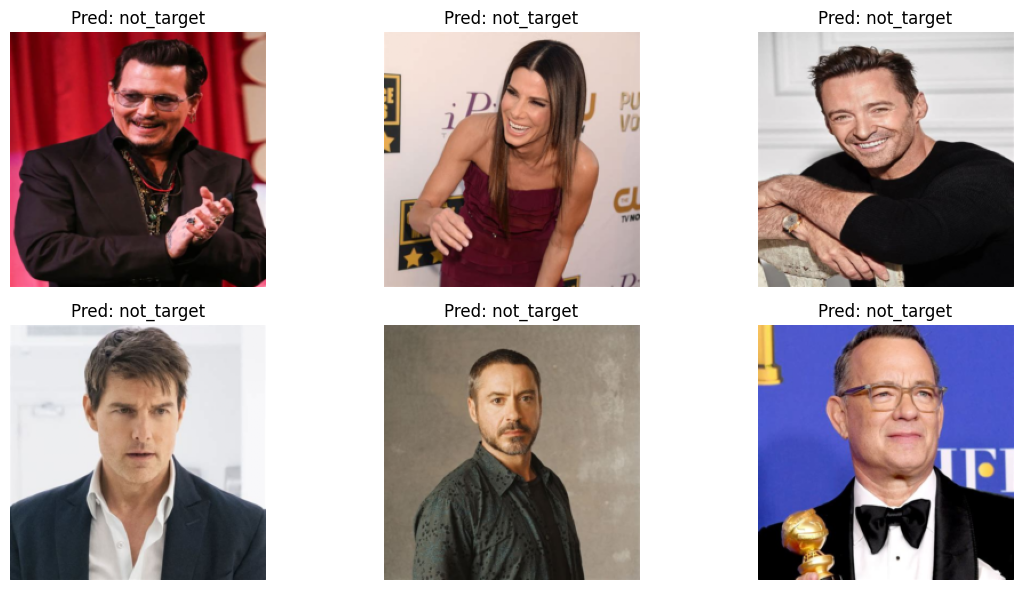

In [27]:
images, labels = next(iter(test_loader))
images = images.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(6):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {class_names[preds[i]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## Saving the Trained Model

In [28]:
torch.save(model.state_dict(), "face_classifier.pth")
print("Model saved as face_classifier.pth")

Model saved as face_classifier.pth


In [29]:
from google.colab import files
files.download("face_classifier.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Conclusion
In this project, I used transfer learning with a pretrained ResNet18 model to classify whether an uploaded face image belongs to Scarlett Johansson or not. The dataset was prepared as a binary classification problem with `target` and `not_target` categories. Data augmentation was used during training, and the final model achieved good performance on the validation and test sets. This trained model can now be used inside a Streamlit application for image upload and prediction.

## References
- PyTorch Transfer Learning Tutorial  
- Torchvision Documentation  
- Kaggle Celebrity Face Image Dataset  
- Streamlit Documentation